In [32]:
"""""
This script is used for the results for the first research question.
Made by: Bram Bouman
date: 17/06/2026
"""

import pandas as pd 

#load in the data:
CR_db = pd.read_csv("processed_CR_db.csv")
patent_db = pd.read_csv("processed_patents.csv")

#drop first column, because it is extra and is not wanted: 
CR_db = CR_db.iloc[:, 1:]
patent_db = patent_db.iloc[:,1:]

#remove all change requests that do not have a technology name: 
CR_db = CR_db.dropna(subset = ["ainame"])
CR_db = CR_db.dropna(subset = ["crspec"])

#change european countries to europe, because they are all their own stakeholder
europe = ["Finland", "France", "Germany", "United Kingdom", "Sweden"]
CR_db["country"] = CR_db["country"].replace(europe, "Europe")
patent_db["country"] = patent_db["country"].replace(europe, "Europe")


C:\Users\Bram\AppData\Local\Temp\ipykernel_95236\3424929854.py:10: DtypeWarning: Columns (0: abstract, 1: secretary_remarks, 2: ainumber, 3: ainame, 4: revisionof, 5: revisedto, 6: release, 7: crspec, 8: crspecversion, 9: workitem, 10: crnumber, 11: uicc_affected, 12: me_affected, 13: ran_affected, 14: cn_affected, 15: clauses_affected, 16: crsinpack) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_db = pd.read_csv("processed_CR_db.csv")


In [33]:
###### based on patent data #######
# Large  : China - United States - South Korea
# Medium : Japan - Finland - Sweden
# Small  : Taiwan - France - Germany - United Kingdom

# noticed that a lot of European stakeholders are only single stakeholders. So; all European countries are put 
# together under the country Europe

###### New country size list #######
# Large: China - United States - Europe
# Medium: Japan - South Korea
# Small: Taiwan (this is still a single stakeholder)

def country_collaboration(df,country):
    country_db = df[df["country"] == f"{country}"]
    
    stakeholders = country_db["source"].unique()
    N_stakeholder = len(stakeholders)
    if N_stakeholder == 0:
        return 0

    num_tech_country = len(country_db["crspec"].unique())
    num_tech_stakeholder_total = 0
    for stakeholder in stakeholders:
        stakeholder_db = country_db[country_db["source"] == f"{stakeholder}"]
        num_tech_stakeholder = len(stakeholder_db["crspec"].unique())
        num_tech_stakeholder_total = num_tech_stakeholder_total + num_tech_stakeholder
    
    country_collab = 1/(N_stakeholder*num_tech_country)*num_tech_stakeholder_total
    return country_collab

answer = country_collaboration(CR_db,"Taiwan")
print(answer)

1.0


         country  amount_patents  country_collaboration_score
0          China          423685                     0.333029
1  United States          411861                     0.252289
4    South Korea          231913                     0.441306
3          Japan          185665                     0.385445
2         Europe          125487                     0.363849


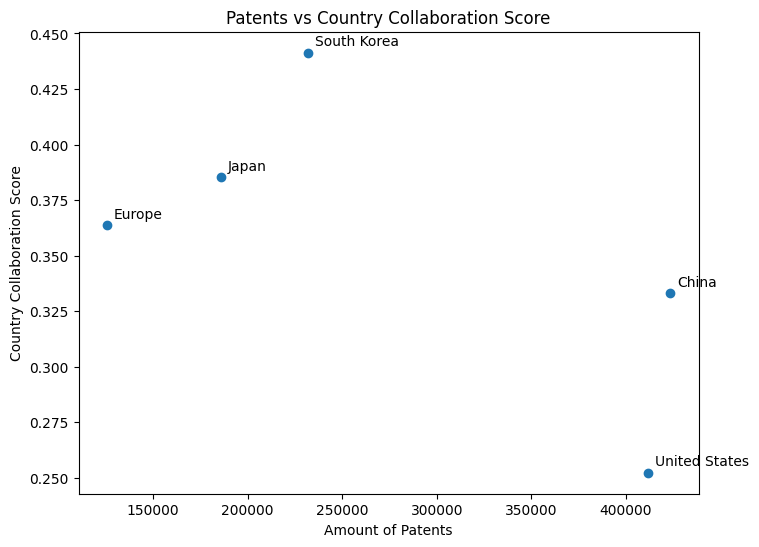

In [46]:
countries = ["China", "United States", "Europe", "Japan", "South Korea"]
amount_patents_country = []
answers = []

for i in countries:
    temp_df = patent_db[patent_db["country"] == f"{i}"]
    patent_country = temp_df["amount_standards"].sum()
    amount_patents_country.append(patent_country)
    answers.append(country_collaboration(CR_db,f"{i}"))

answer_df = pd.DataFrame({
    "country": countries,
    "amount_patents": amount_patents_country,
    "country_collaboration_score": answers
})


answer_df = answer_df.sort_values(by = "amount_patents", ascending= False)
print(answer_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    answer_df["amount_patents"],
    answer_df["country_collaboration_score"],
)

# Add country labels next to each dot
for _, row in answer_df.iterrows():
    plt.annotate(
        row["country"],
        (row["amount_patents"], row["country_collaboration_score"]),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.xlabel("Amount of Patents")
plt.ylabel("Country Collaboration Score")
plt.title("Patents vs Country Collaboration Score")
plt.show()

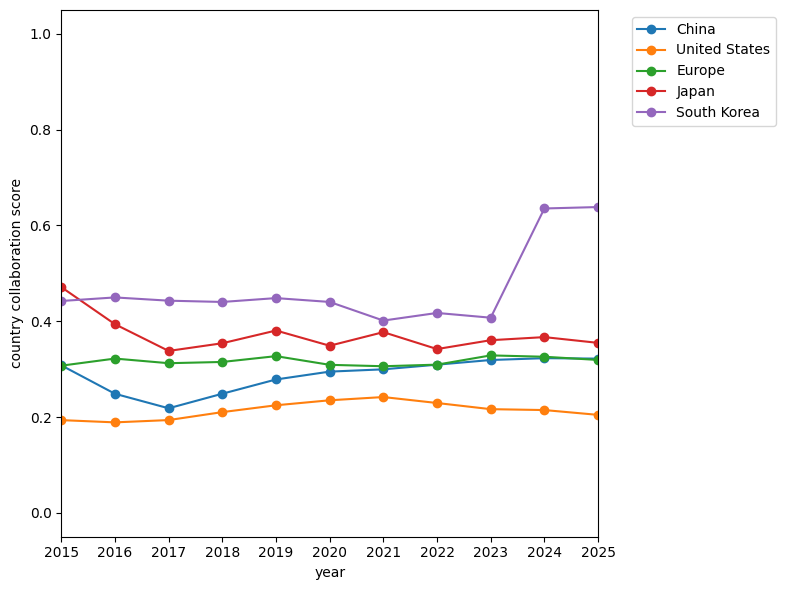

In [35]:
countries = ["China", "United States", "Europe", "Japan", "South Korea"]
amount_patents_country = []
answers = []

test_CR_df = CR_db[CR_db["year"] == 2014]
answer_country_collab_score = pd.DataFrame(columns = countries)
years = list(range(2014,2026))
#starting from 2014, because before this year there was no info about technology
for i in years: 
    year_CR_df = CR_db[CR_db["year"] == i]

    temp_results = []
    #maak dit voor alle landen, daarna maak hiermee entry in database. zo vul je elk jaar op.
    china = country_collaboration(year_CR_df, "China")
    europe = country_collaboration(year_CR_df, "Europe")
    united_states = country_collaboration(year_CR_df, "United States")
    south_korea = country_collaboration(year_CR_df, "South Korea")
    japan = country_collaboration(year_CR_df, "Japan")
    
    temp_results = [china, united_states, europe, japan, south_korea]
    answer_country_collab_score.loc[len(answer_country_collab_score)] = temp_results 


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for column in answer_country_collab_score.columns:
    plt.plot(years,answer_country_collab_score[column],marker = 'o', label = column)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("year")
plt.ylabel("country collaboration score")
plt.xlim(2015,2025)
plt.xticks(range(2015, 2026))
plt.tight_layout()
plt.show()





Correlation: -0.6650099476011881
P-value: 0.2206758520612386
Intercept: 0.44989854143183516
Slope: -3.435160987238265e-07
R-squared:  0.44223823040853494


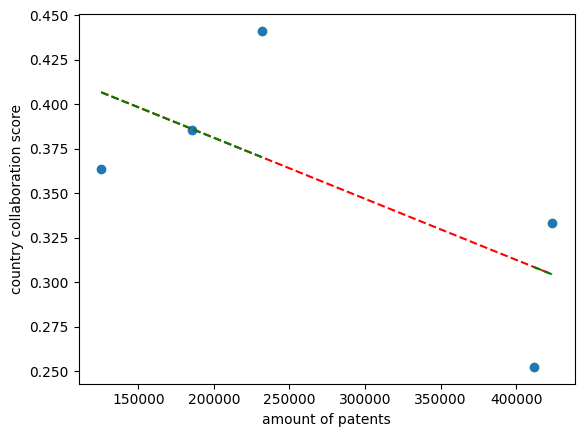

In [37]:
from scipy.stats import pearsonr
r, p_value = pearsonr(answer_df["amount_patents"], answer_df["country_collaboration_score"])
print("Correlation:", r)
print("P-value:", p_value)

import matplotlib.pyplot as plt
plt.figure()
plt.scatter(answer_df["amount_patents"], answer_df["country_collaboration_score"])
plt.xlabel("amount of patents")
plt.ylabel("country collaboration score")

answer_df = answer_df.sort_values(by="amount_patents", ascending=True)

from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(answer_df["amount_patents"]).reshape(-1, 1)
y = np.array(answer_df["country_collaboration_score"])

model = LinearRegression()
model.fit(X, y)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# predictions for regression line
y_pred = model.predict(X)

# plot regression line
plt.plot(X, y_pred, color="red", label="Regression line", linestyle = "--")

r2 = model.score(X, y)
print("R-squared: ",r2)


## why be careful
X = np.array(answer_df.head(3)["amount_patents"]).reshape(-1, 1)
y = np.array(answer_df.head(3)["country_collaboration_score"])
y_pred = model.predict(X)
# plot regression line
plt.plot(X, y_pred, color="green", linestyle = "--")


X = np.array(answer_df.tail(2)["amount_patents"]).reshape(-1, 1)
y = np.array(answer_df.tail(2)["country_collaboration_score"])
y_pred = model.predict(X)
# plot regression line
plt.plot(X, y_pred, color="green", linestyle = "--")
plt.show()





C:\Users\Bram\AppData\Local\Temp\ipykernel_95236\4127069272.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "g--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot(x_line_tail, model_tail.predict(x_line_tail), "g--", linestyle="--")


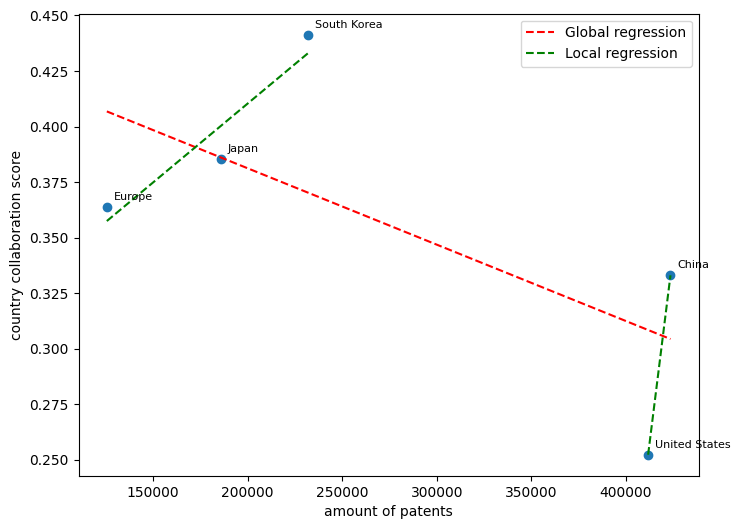

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# full data
X_full = np.array(answer_df["amount_patents"]).reshape(-1, 1)
y_full = np.array(answer_df["country_collaboration_score"])

model_full = LinearRegression().fit(X_full, y_full)

# -------------------------
# FIRST 3 POINTS MODEL
# -------------------------
df_head = answer_df.head(3).sort_values("amount_patents")
X_head = np.array(df_head["amount_patents"]).reshape(-1, 1)
y_head = np.array(df_head["country_collaboration_score"])

model_head = LinearRegression().fit(X_head, y_head)

# -------------------------
# LAST 2 POINTS MODEL
# -------------------------
df_tail = answer_df.tail(2).sort_values("amount_patents")
X_tail = np.array(df_tail["amount_patents"]).reshape(-1, 1)
y_tail = np.array(df_tail["country_collaboration_score"])

model_tail = LinearRegression().fit(X_tail, y_tail)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(8, 6))
plt.scatter(X_full, y_full)

# Add country labels
for _, row in answer_df.iterrows():
    plt.annotate(
        row["country"],
        (row["amount_patents"], row["country_collaboration_score"]),
        xytext=(5, 5),          # offset from the point
        textcoords="offset points",
        fontsize=8
    )

# full regression line
x_line = np.linspace(X_full.min(), X_full.max(), 100).reshape(-1, 1)
plt.plot(x_line, model_full.predict(x_line), "r--", label="Global regression")

# head regression line
x_line_head = np.linspace(X_head.min(), X_head.max(), 50).reshape(-1, 1)
plt.plot(x_line_head, model_head.predict(x_line_head), "g--", label="Local regression")

# tail regression line
x_line_tail = np.linspace(X_tail.min(), X_tail.max(), 50).reshape(-1, 1)
plt.plot(x_line_tail, model_tail.predict(x_line_tail), "g--", linestyle="--")

plt.xlabel("amount of patents")
plt.ylabel("country collaboration score")
plt.legend()
plt.show()

In [49]:
answer_df_top = answer_df.head(2)
answer_df_bot = answer_df.tail(3)

from scipy.stats import pearsonr
r, p_value = pearsonr(answer_df_top["amount_patents"], answer_df_top["country_collaboration_score"])
print("Correlation for first 2:", r)
print("P-value for first 2:", p_value)

from scipy.stats import pearsonr
r, p_value = pearsonr(answer_df_bot["amount_patents"], answer_df_bot["country_collaboration_score"])
print("Correlation for last 3:", r)
print("P-value for last 3:", p_value)

Correlation for first 2: 1.0
P-value for first 2: 1.0
Correlation for last 3: 0.9474959010439118
P-value for last 3: 0.20720988630535236
